# RQ2: do sparse features only activate on similar images?

The SAE paper shows sparse dimensions that each have a clear meaning: one fires on
cigarettes, one on ships, and so on, and the images that activate it all share that
theme. We check whether that holds for our smaller efficientnet and mobilenet SAEs,
or whether most dimensions fire on a random mix of images.

We use the `image_to_sparse` analysis: for each dimension we have the images that
activate it (the gallery) and, for the strongest activators, a heatmap showing which
part of the image drove the activation.

First a demo to browse single dimensions, then the final illustrative figure.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

OUTPUT = Path("output")
RUNS = {
    "efficientnet": "efficientnet_adamw_l10.0004_lr0.001_x32_e200_b4096_n100000_seed0",
    "mobilenet": "mobilenet_adamw_l10.0004_lr0.001_x32_e200_b4096_n100000_seed0",
}


def activators_dir(model: str) -> Path:
    """The shared per-dimension activator galleries for a model."""
    return OUTPUT / RUNS[model] / "image_to_sparse" / "activators" / "dimensions"


def method_dir(model: str, method: str) -> Path:
    """An image_to_sparse method folder, for its attribution heatmaps."""
    base = OUTPUT / RUNS[model] / "image_to_sparse"
    return next(d for d in base.iterdir() if d.name.startswith(method))

## Demo: browse a single dimension

Change `DIM` to look at any dimension. The gallery shows the images that activate it
most; the activator labels tell you whether they share a theme; the heatmaps show
what part of each image caused the activation.

In [2]:
MODEL = "efficientnet"
METHOD = "integrated_gradients"

# the dimensions that actually got attribution heatmaps (an image's top-k)
attributed = sorted(int(p.name) for p in (method_dir(MODEL, METHOD) / "dimensions").iterdir())
print(f"{len(attributed)} dimensions have attribution heatmaps, e.g. {attributed[:8]}")
DIM = attributed[0]

342 dimensions have attribution heatmaps, e.g. [111, 177, 337, 465, 512, 547, 854, 1049]


In [3]:
# the labels of the images that activate this dimension (do they share a theme?)
info = json.load(open(activators_dir(MODEL) / str(DIM) / "activators.json"))
print(f"dimension {DIM}: {len(info)} activating images")
print("top activators (label, activation):")
for a in info[:10]:
    print(f"  {a['activation']:.3f}  {a['label_name']}")

dimension 111: 190 activating images
top activators (label, activation):
  0.122  American chameleon, anole, Anolis carolinensis
  0.113  green lizard, Lacerta viridis
  0.110  red wine
  0.103  prison, prison house
  0.095  green lizard, Lacerta viridis
  0.093  marimba, xylophone
  0.093  screwdriver
  0.080  stone wall
  0.079  slide rule, slipstick
  0.077  plow, plough


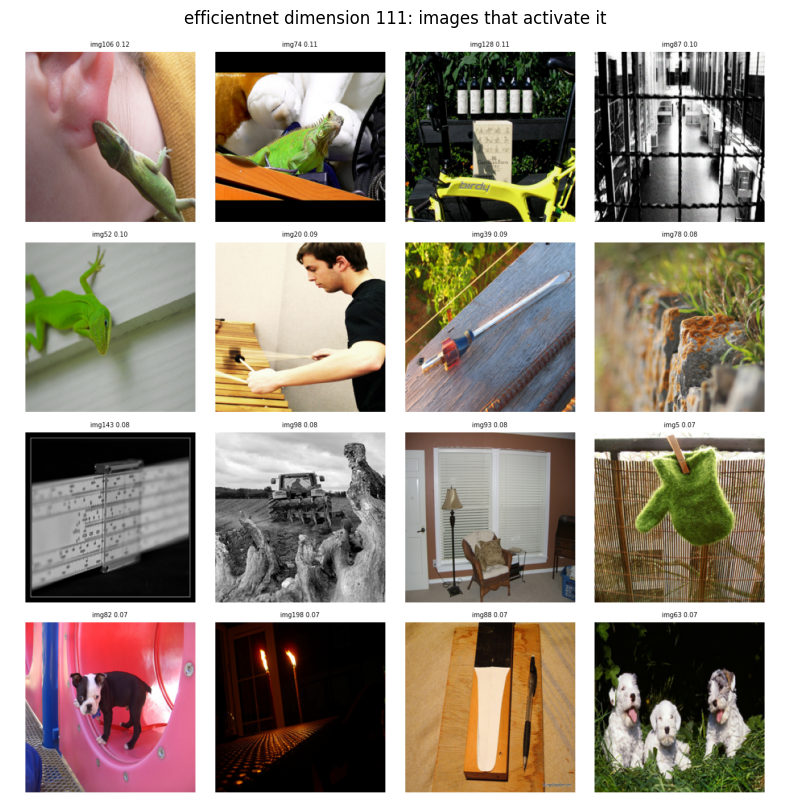

In [4]:
# the pre-rendered gallery of images that activate this dimension
gallery = activators_dir(MODEL) / str(DIM) / "activators.png"
plt.figure(figsize=(10, 10))
plt.imshow(mpimg.imread(gallery))
plt.axis("off")
plt.title(f"{MODEL} dimension {DIM}: images that activate it")
plt.show()

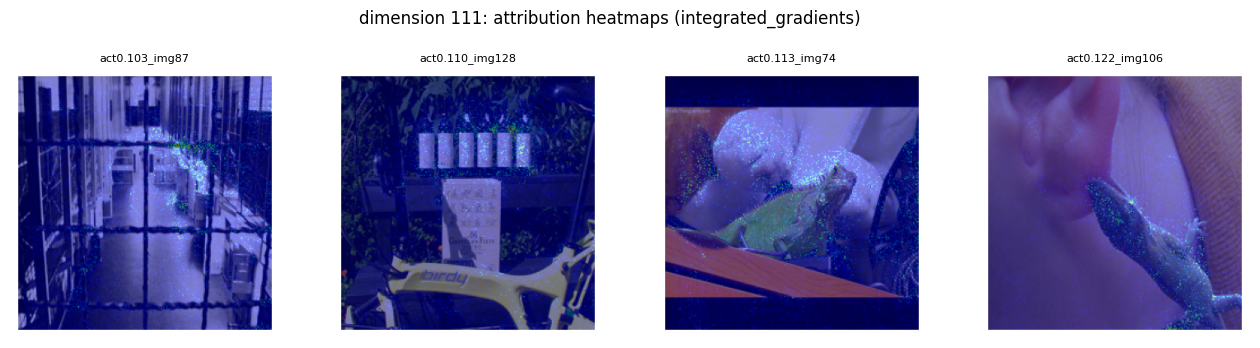

In [5]:
# the attribution heatmaps for this dimension: which pixels drove the activation
heatmaps = sorted((method_dir(MODEL, METHOD) / "dimensions" / str(DIM) / "attributions").glob("*.png"))
fig, axes = plt.subplots(1, len(heatmaps), figsize=(4 * len(heatmaps), 4), squeeze=False)
for ax, h in zip(axes[0], heatmaps):
    ax.imshow(mpimg.imread(h))
    ax.axis("off")
    ax.set_title(h.stem, fontsize=8)
fig.suptitle(f"dimension {DIM}: attribution heatmaps ({METHOD})")
plt.show()

## Final figure: interpretable vs non-interpretable dimensions

This is an illustrative diagram, not a measured result. It shows the two cases we
find: sometimes a dimension's activating images share a clear theme (an
interpretable feature, like the paper's cigarette feature), but most of the time
they do not (a non-interpretable feature). The images here are hand picked to make
the point; the percentages are placeholders for the numbers from our qualitative
analysis of a sample of dimensions.

We stream a few real ImageNet images for the panels: a coherent set (all birds)
and an incoherent set (a random mix). Needs huggingface login (see the README).

In [6]:
from datasets import load_dataset

# PLACEHOLDERS: replace with the fractions from the qualitative analysis
PERCENT_INTERPRETABLE = 20
PERCENT_NOT_INTERPRETABLE = 80

# imagenet class ids: a coherent set (all birds) and an incoherent mix
COHERENT = [10, 11, 12, 13]            # birds: brambling, goldfinch, house finch, junco
INCOHERENT = [291, 817, 980, 504]      # lion, sports car, volcano, coffee mug


def grab_images(class_ids):
    """Stream one validation image per class id."""
    wanted = set(class_ids)
    found = {}
    stream = load_dataset("ILSVRC/imagenet-1k", split="validation", streaming=True)
    for ex in stream:
        if ex["label"] in wanted and ex["label"] not in found:
            found[ex["label"]] = ex["image"].convert("RGB")
        if len(found) == len(wanted):
            break
    return [found[c] for c in class_ids]


coherent_imgs = grab_images(COHERENT)
incoherent_imgs = grab_images(INCOHERENT)
print("got", len(coherent_imgs), "coherent and", len(incoherent_imgs), "incoherent images")

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

got 4 coherent and 4 incoherent images


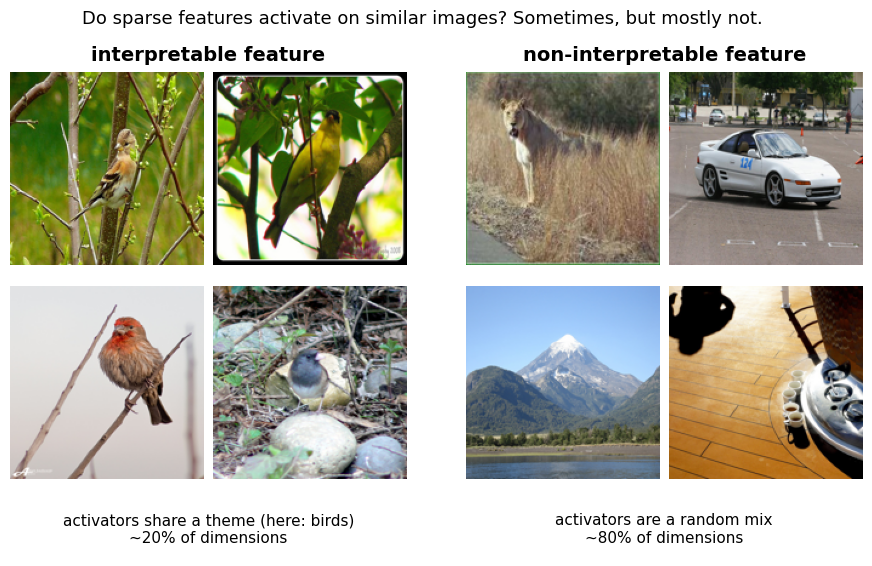

In [15]:
import numpy as np

fig = plt.figure(figsize=(11, 6.5))
# two panels side by side, each with its own 2x2 image grid and room for text
outer = fig.add_gridspec(1, 2, wspace=0.15)


def panel(slot, images, title, subtitle):
    """Draw a 2x2 grid of images with a title above and a caption below."""
    # rows: small title, the 2x2 images, small caption
    inner = slot.subgridspec(
        4, 2, height_ratios=[0, 2, 2, 0.6], hspace=0.1, wspace=0.05
    )
    title_ax = fig.add_subplot(inner[0, :])
    title_ax.axis("off")
    title_ax.text(0.5, 0.3, title, ha="center", va="center", fontsize=14, weight="bold")
    for k, img in enumerate(images):
        ax = fig.add_subplot(inner[1 + k // 2, k % 2])
        ax.imshow(img.resize((160, 160)))
        ax.axis("off")
    cap_ax = fig.add_subplot(inner[3, :])
    cap_ax.axis("off")
    cap_ax.text(0.5, 0.7, subtitle, ha="center", va="top", fontsize=11)


panel(
    outer[0],
    coherent_imgs,
    "interpretable feature",
    f"activators share a theme (here: birds)\n~{PERCENT_INTERPRETABLE}% of dimensions",
)
panel(
    outer[1],
    incoherent_imgs,
    "non-interpretable feature",
    f"activators are a random mix\n~{PERCENT_NOT_INTERPRETABLE}% of dimensions",
)

fig.suptitle(
    "Do sparse features activate on similar images? Sometimes, but mostly not.",
    fontsize=13,
    y=0.95,
)
fig.savefig("rq2_interpretability.png", dpi=130, bbox_inches="tight")
plt.show()